In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = {
    "Outlook": [
        "Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
        "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain",
        "Sunny","Rain","Overcast","Sunny","Rain","Overcast"
    ],

    "Temp": [
        "Hot","Hot","Hot","Mild","Cool","Cool","Cool",
        "Mild","Cool","Mild","Mild","Mild","Hot","Mild",
        "Cool","Hot","Mild","Cool","Mild","Hot"
    ],

    "Humidity": [
        "High","High","High","High","Normal","Normal","Normal",
        "High","Normal","Normal","Normal","High","Normal","High",
        "Normal","High","Normal","High","Normal","High"
    ],

    "Wind": [
        "Weak","Strong","Weak","Weak","Weak","Strong","Strong",
        "Weak","Weak","Weak","Strong","Strong","Weak","Strong",
        "Weak","Strong","Weak","Strong","Weak","Strong"
    ],

    # Regression target
    "Golf_Players": [
        25,30,46,45,52,23,43,
        35,38,46,48,52,44,30,
        39,28,47,33,49,41
    ]
}

df = pd.DataFrame(data)
df

,Outlook,Temp,Humidity,Wind,Golf_Players
0,Sunny,Hot,High,Weak,25
1,Sunny,Hot,High,Strong,30
2,Overcast,Hot,High,Weak,46
3,Rain,Mild,High,Weak,45
4,Rain,Cool,Normal,Weak,52
5,Rain,Cool,Normal,Strong,23
6,Overcast,Cool,Normal,Strong,43
7,Sunny,Mild,High,Weak,35
8,Sunny,Cool,Normal,Weak,38
9,Rain,Mild,Normal,Weak,46


In [3]:
df_encoded = df.copy()

category_maps = {}

for col in ["Outlook","Temp","Humidity","Wind"]:
    df_encoded[col] = df[col].astype("category").cat.codes
    category_maps[col] = dict(enumerate(df[col].astype("category").cat.categories))

df_encoded

,Outlook,Temp,Humidity,Wind,Golf_Players
0,2,1,0,1,25
1,2,1,0,0,30
2,0,1,0,1,46
3,1,2,0,1,45
4,1,0,1,1,52
5,1,0,1,0,23
6,0,0,1,0,43
7,2,2,0,1,35
8,2,0,1,1,38
9,1,2,1,1,46


In [4]:
def std_dev(y):
    return np.std(y)

In [5]:
def best_split(X, y):
    best_feature = None
    best_category = None
    best_sd = float("inf")

    for feature in X.columns:
        values = np.unique(X[feature])

        for val in values:
            left_mask = (X[feature] == val)
            right_mask = (X[feature] != val)

            if sum(left_mask) == 0 or sum(right_mask) == 0:
                continue

            left = y[left_mask]
            right = y[right_mask]

            weighted_sd = (
                len(left)/len(y) * std_dev(left) +
                len(right)/len(y) * std_dev(right)
            )

            if weighted_sd < best_sd:
                best_feature = feature
                best_category = val
                best_sd = weighted_sd

    return best_feature, best_category

In [6]:
global_mean = np.mean(df_encoded["Golf_Players"])

def build_tree(X, y, depth=0, max_depth=3):

    node = {}
    node["std_dev"] = round(std_dev(y), 3)

    # Stopping condition
    if depth >= max_depth or std_dev(y) < 2:
        node["type"] = "leaf"
        node["label"] = "Yes" if np.mean(y) >= global_mean else "No"
        return node

    feature, category = best_split(X, y)

    if feature is None:
        node["type"] = "leaf"
        node["label"] = "Yes" if np.mean(y) >= global_mean else "No"
        return node

    node["type"] = "node"
    node["feature"] = feature
    node["category"] = category_maps[feature][category]

    left_mask = (X[feature] == category)
    right_mask = (X[feature] != category)

    node["left"] = build_tree(X[left_mask], y[left_mask], depth+1, max_depth)
    node["right"] = build_tree(X[right_mask], y[right_mask], depth+1, max_depth)

    return node

In [7]:
X = df_encoded.drop("Golf_Players", axis=1)
y = df_encoded["Golf_Players"]

tree = build_tree(X, y)
tree

{'std_dev': 8.776,
 'type': 'node',
 'feature': 'Outlook',
 'category': 'Overcast',
 'left': {'std_dev': 3.5,
  'type': 'node',
  'feature': 'Temp',
  'category': 'Mild',
  'left': {'std_dev': 2.5,
   'type': 'node',
   'feature': 'Humidity',
   'category': 'High',
   'left': {'std_dev': 0.0, 'type': 'leaf', 'label': 'Yes'},
   'right': {'std_dev': 0.0, 'type': 'leaf', 'label': 'Yes'}},
  'right': {'std_dev': 1.803, 'type': 'leaf', 'label': 'Yes'}},
 'right': {'std_dev': 9.174,
  'type': 'node',
  'feature': 'Temp',
  'category': 'Hot',
  'left': {'std_dev': 2.055,
   'type': 'node',
   'feature': 'Wind',
   'category': 'Strong',
   'left': {'std_dev': 1.0, 'type': 'leaf', 'label': 'No'},
   'right': {'std_dev': 0.0, 'type': 'leaf', 'label': 'No'}},
  'right': {'std_dev': 8.622,
   'type': 'node',
   'feature': 'Wind',
   'category': 'Strong',
   'left': {'std_dev': 9.124, 'type': 'leaf', 'label': 'No'},
   'right': {'std_dev': 5.778, 'type': 'leaf', 'label': 'Yes'}}}}

In [8]:
def plot_tree(node, x, y, dx, dy, ax):

    if node["type"] == "leaf":
        text = f"Leaf\nClass={node['label']}\nSD={node['std_dev']}"
        ax.text(x, y, text, ha='center',
                bbox=dict(boxstyle="round"))
        return

    text = f"{node['feature']} ?\nSD={node['std_dev']}"
    ax.text(x, y, text, ha='center',
            bbox=dict(boxstyle="round"))

    # Left branch (feature = category)
    ax.plot([x, x-dx], [y, y-dy])
    ax.text(x-dx/2, y-dy/2,
            f"{node['feature']} = {node['category']}",
            ha='center')
    plot_tree(node["left"], x-dx, y-dy, dx/2, dy, ax)

    # Right branch (feature ≠ category)
    ax.plot([x, x+dx], [y, y-dy])
    ax.text(x+dx/2, y-dy/2,
            f"{node['feature']} ≠ {node['category']}",
            ha='center')
    plot_tree(node["right"], x+dx, y-dy, dx/2, dy, ax)

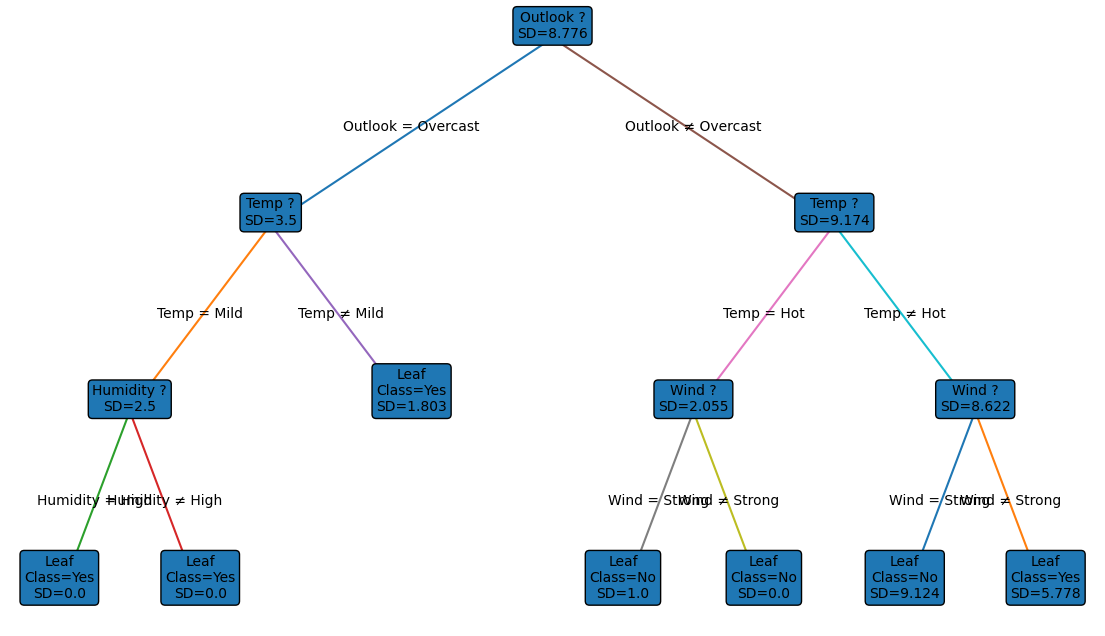

In [9]:
fig, ax = plt.subplots(figsize=(14,8))
ax.set_axis_off()

plot_tree(tree, x=0.5, y=1, dx=0.25, dy=0.2, ax=ax)

plt.show()